In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam


In [2]:
df = pd.read_csv("boston_house_prices.csv")


In [3]:
print(df.head())


      CRIM    ZN  INDUS  CHAS    NOX     RM   AGE     DIS  RAD  TAX  PTRATIO  \
0  0.00632  18.0   2.31     0  0.538  6.575  65.2  4.0900    1  296     15.3   
1  0.02731   0.0   7.07     0  0.469  6.421  78.9  4.9671    2  242     17.8   
2  0.02729   0.0   7.07     0  0.469  7.185  61.1  4.9671    2  242     17.8   
3  0.03237   0.0   2.18     0  0.458  6.998  45.8  6.0622    3  222     18.7   
4  0.06905   0.0   2.18     0  0.458  7.147  54.2  6.0622    3  222     18.7   

        B  LSTAT  PRICE  
0  396.90   4.98   24.0  
1  396.90   9.14   21.6  
2  392.83   4.03   34.7  
3  394.63   2.94   33.4  
4  396.90   5.33   36.2  


In [4]:
X = df.drop(columns=['PRICE'])   # Target column is MEDV (price)
y = df['PRICE']

In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)


In [6]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [7]:
model = Sequential()


In [8]:
model.add(Dense(64,activation='relu',input_shape=(X_train.shape[1],)))
model.add(Dense(32,activation='relu'))
model.add(Dense(16,activation='relu'))

C:\Users\Jaydeep Tamkhane\AppData\Roaming\Python\Python313\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [9]:
model.add(Dense(1))


In [10]:
model.compile(
    optimizer=Adam(learning_rate=0.01),
    loss='mse',
    metrics=['mae']
)

In [11]:
history = model.fit(
    X_train, y_train,
    validation_split=0.1,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 390.9029 - mae: 16.7664 - val_loss: 70.6683 - val_mae: 6.1465
Epoch 2/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 39.8351 - mae: 4.8099 - val_loss: 42.6143 - val_mae: 4.4975
Epoch 3/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 19.4128 - mae: 3.2219 - val_loss: 29.5293 - val_mae: 3.5410
Epoch 4/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 15.6214 - mae: 2.8467 - val_loss: 21.3166 - val_mae: 3.2270
Epoch 5/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.1359 - mae: 2.8115 - val_loss: 24.0388 - val_mae: 3.2953
Epoch 6/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.0467 - mae: 2.7404 - val_loss: 24.2953 - val_mae: 3.3561
Epoch 7/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 11.9674 - mae: 2.5345 - val_loss: 21.4892 - val_mae: 3.1245
Epoch 8/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 14.3856 - mae: 2.7142 - val_loss: 20.4471 - val_mae: 2.9614
Epoch 9/100
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/

In [12]:
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss (MSE):", loss)
print("Test MAE:", mae)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 11.0949 - mae: 2.2585
Test Loss (MSE): 11.094894409179688
Test MAE: 2.258488893508911


In [13]:
y_pred = model.predict(X_test)


4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step


In [14]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred.flatten()
})
print(comparison.head())


   Actual  Predicted
0    23.6  24.970303
1    32.4  32.959133
2    13.6  15.177401
3    22.8  24.199085
4    16.1  16.702337


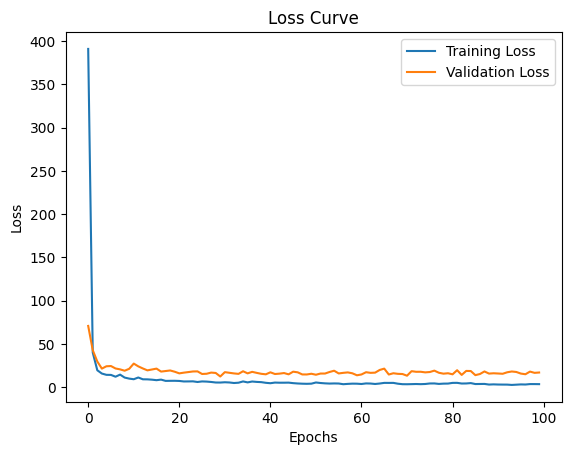

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title("Loss Curve")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.show()